# <font color = Blue> **Trabalho T1 - Estatística Descritia Univariada e Bivariada**

### **Membros do grupo**

Maria Luisa Bittencourt Bomfim - 25896929

### **Objetivo do trabalho**
Fazer uma Análise Estatística Descritiva dos dados

**Importanto as bibliotecas básicas para análise estatística de dados**

In [145]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

- **Importando a base de dados - Titanic**

O dataset contém dados reais dos passageiros do Titanic.

In [157]:
df = sns.load_dataset("titanic")

#traduzindo
df['sobreviventes'] = df['survived'].map({0: 'Morreu', 1: 'Sobreviveu'})
df['Sexo'] = df['sex'].map({'male': 'Masculino', 'female': 'Femino'})
df['Classe_Econômica']=df['class'].map({'First': 'Primeira', 'Second': 'Segunda', 'Third': 'Terceira'})
df['Sozinho'] = df['alone'].map({True: 'Sim', False: 'Não'})

df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,sobreviventes,Sexo,Classe_Econômica,Sozinho
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,Morreu,Masculino,Terceira,Não
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Sobreviveu,Femino,Primeira,Não
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Sobreviveu,Femino,Terceira,Sim
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Sobreviveu,Femino,Primeira,Não
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,Morreu,Masculino,Terceira,Sim
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,Morreu,Masculino,Segunda,Sim
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,Sobreviveu,Femino,Primeira,Sim
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,Morreu,Femino,Terceira,Não
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,Sobreviveu,Masculino,Primeira,Sim


## **Desenvolvimento do trabalho (Análise Exploratória dos Dados)**

**Primeira informação**

> Idade dos passageiros:

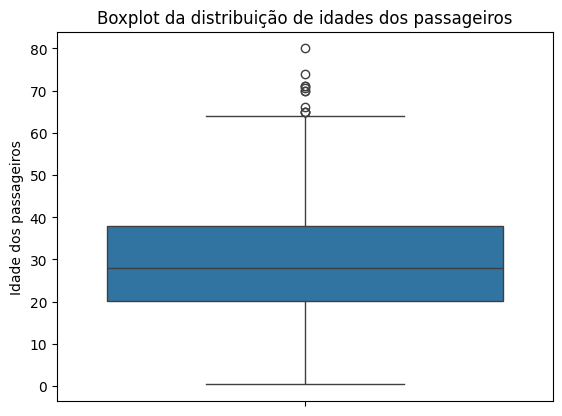

Valor do Q1: 20.12 
Valor do Q3: 38.0
Metade das pessoas:  445.5


In [147]:
plt.title("Boxplot da distribuição de idades dos passageiros")
plt.ylabel("Idade dos passageiros")
sns.boxplot(data = df.age)
plt.show()

q3 = round(df.age.quantile(0.75),2)
q1 = round(df.age.quantile(0.25),2)

print("Valor do Q1:",q1, "\nValor do Q3:", q3)

qtd_total = len(df)
metade = qtd_total*0.5
print("Metade das pessoas: ", metade)

**Segunda informação**

> Taxa de sobrevivência por tarifa paga:



/tmp/ipykernel_2360/614135752.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y="fare", x="sobreviventes", fliersize=0, palette=cores)
/tmp/ipykernel_2360/614135752.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabela = round(df.groupby('faixa_fare')['survived'].mean() * 100,2)


,Faixa de Tarifa,(%)sobrevivência
0,barata,20.56
1,média,42.03
2,cara,65.42
3,muito cara,73.58


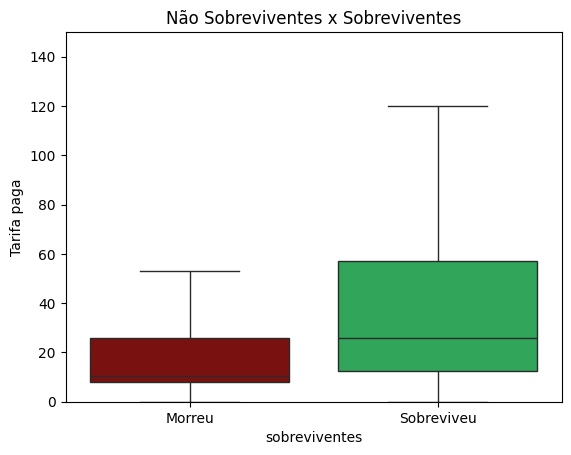

In [156]:
plt.ylim(0,150)
plt.title("Não Sobreviventes x Sobreviventes")
plt.ylabel("Tarifa paga")
sns.boxplot(data=df, y="fare", x="sobreviventes", fliersize=0, palette=cores)

df['faixa_fare'] = pd.cut(df.fare, bins=[0, 10, 50, 100, 600], labels=['barata', 'média', 'cara', 'muito cara'])

tabela = round(df.groupby('faixa_fare')['survived'].mean() * 100,2)
tabela = tabela.reset_index()
tabela.columns = ['Faixa de Tarifa', '(%)sobrevivência']

display(tabela)


**Terceira informação**

> Taxa de sobrevivência separada por sexo:

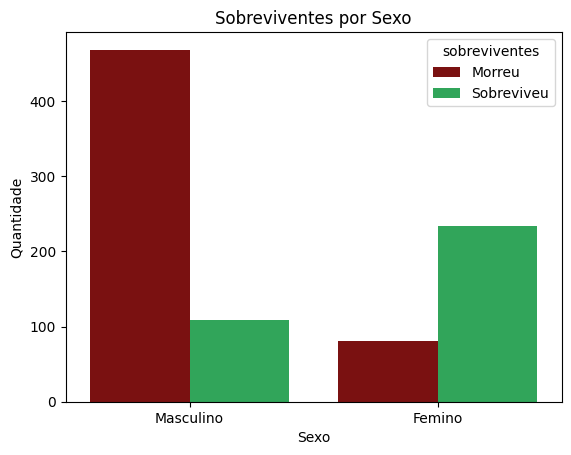

passageiros do sexo feminino: 314 
passageiros do sexo masculino: 577
Sobreviventes feminino: 233
Sobreviventes masculino: 109
porcentagem de sobreviventes mulheres: 74.2 porcentagem de sobreviventes homens: 18.89
A taxa de sobrevivência das mulheres foi 3.93 vezes mais que a dos homens


In [149]:
cores = {
    'Morreu': '#8B0000',   #  morto
    'Sobreviveu':  '#1DB954'    #  vivo
}
sns.countplot(data=df, x="Sexo", hue="sobreviventes", palette=cores)
plt.xlabel('Sexo')
plt.ylabel('Quantidade')
plt.title('Sobreviventes por Sexo')
plt.show()

sexo = df[['sex']]
contfem = (sexo.sex == 'female').sum()
contmasc = (sexo.sex == 'male').sum()                #qnts de cada sexo
print("passageiros do sexo feminino:", contfem, "\npassageiros do sexo masculino:", contmasc)


# Filtrando apenas sobreviventes
sobreviventes = df[df['survived'] == 1]
# Contando por sexo
sobrev_fem = (sobreviventes['sex'] == 'female').sum()
sobrev_masc = (sobreviventes['sex'] == 'male').sum()

print("Sobreviventes feminino:", sobrev_fem)
print("Sobreviventes masculino:", sobrev_masc)

porcM = round((sobrev_fem/contfem)*100, 2)            #porcentagem final
porcH = round((sobrev_masc/contmasc)*100, 2)

print("porcentagem de sobreviventes mulheres:",porcM,"porcentagem de sobreviventes homens:", porcH)
print("A taxa de sobrevivência das mulheres foi", round(porcM/porcH, 2), "vezes mais que a dos homens")

**Quarta informação**

> Média das tarifas separadas por cidade:

,Cidade,Tarifa(1°Classe),Tarifa(2°Classe),Tarifa(3°Classe)
0,C,71.54,25.36,11.21
1,Q,90.00,12.35,7.72
2,S,57.25,18.06,10.53


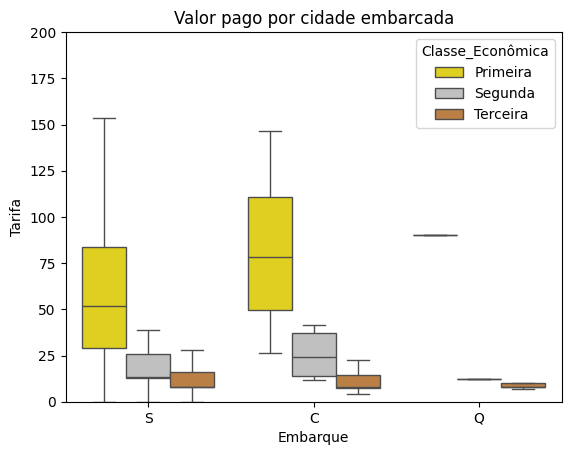

In [150]:
cores2 = {
    'Primeira':   '#FFEA00',
    'Segunda':  '#C0C0C0',
    'Terceira': '#CD7F32'
}

sns.boxplot(data= df, x=df.embarked, y=df.fare, hue= "Classe_Econômica", fliersize = 0, palette=cores2)
plt.ylim(0,200)
plt.xlabel('Embarque')
plt.ylabel('Tarifa')
plt.title('Valor pago por cidade embarcada')

def media_sem_outliers(x):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    return x[(x >= q1 - 1.5*iqr) & (x <= q3 + 1.5*iqr)].mean()


media2 = round(df[df['class'] == 'Second'].groupby('embarked')['fare'].apply(media_sem_outliers),2)
media2 = media2.reset_index()
media2.columns = ['Cidade', 'Tarifa(2°Classe)']

media1 = round(df[df['class'] == 'First'].groupby('embarked')['fare'].apply(media_sem_outliers),2)
media1 = media1.reset_index()
media1.columns = ['Cidade', 'Tarifa(1°Classe)']

media3 = round(df[df['class'] == 'Third'].groupby('embarked')['fare'].apply(media_sem_outliers),2)
media3 = media3.reset_index()
media3.columns = ['Cidade', 'Tarifa(3°Classe)']

tabela_final = media1.merge(media2, on='Cidade').merge(media3, on='Cidade')
display(tabela_final)

**Quinta informação**

> Análise das mortes de passageiros que viajaram sozinhos VS passageiros que viajaram acompanhados:

Porcentagem de pessoas sobreviventes que estavam acompanhadas: 50.56 
Porcentagem de pessoas sobreviventes que estavam sozinhas: 30.35




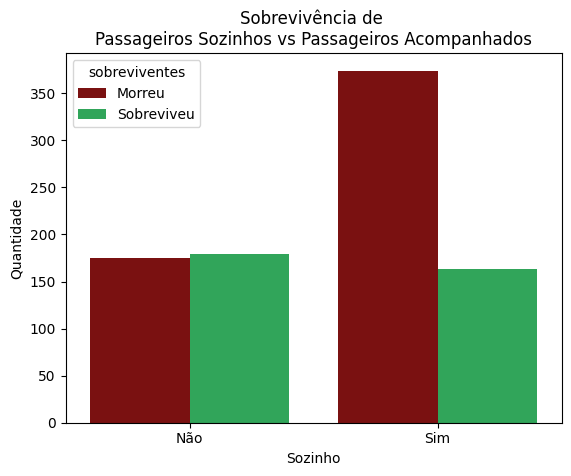

In [151]:
sns.countplot(data=df, x="Sozinho", hue="sobreviventes", palette=cores)
plt.ylabel('Quantidade')
plt.title('Sobrevivência de \nPassageiros Sozinhos vs Passageiros Acompanhados')
P_alone = df[['alone', 'survived']]

alonefalse_survived = len(P_alone[(P_alone.alone == False) & (P_alone.survived == 1)])
qtd_false = len(P_alone[P_alone.alone == False])
percent_nonAlone_survived = round((alonefalse_survived/qtd_false)*100,2)

aloneTrue_survived = len(P_alone[(P_alone.alone == True) & (P_alone.survived == 1)])
qtd_true = len(P_alone[P_alone.alone == True])
percent_Alone_survived = round((aloneTrue_survived/qtd_true)*100,2)

print("Porcentagem de pessoas sobreviventes que estavam acompanhadas:", percent_nonAlone_survived,"\nPorcentagem de pessoas sobreviventes que estavam sozinhas:", percent_Alone_survived)
print("\n")